In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
scheme_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
txn_df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

print(nav_df.shape)
print(scheme_df.shape)
print(txn_df.shape)

(46000, 3)
(40, 19)
(32778, 13)


In [2]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_pivot = nav_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns_df = nav_pivot.pct_change().dropna()

returns_df.head()


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


In [4]:
var_95 = returns_df.quantile(0.05)

var_95.head()

amfi_code
100016   -0.014364
100025   -0.003793
100033   -0.019034
101206   -0.013282
101207   -0.026021
Name: 0.05, dtype: float64

In [5]:
cvar_95 = returns_df.apply(
    lambda x: x[x <= x.quantile(0.05)].mean()
)

cvar_95.head()

amfi_code
100016   -0.018060
100025   -0.004994
100033   -0.023456
101206   -0.017439
101207   -0.032459
dtype: float64

In [6]:
var_cvar_report = pd.DataFrame({
    "VaR_95": var_95,
    "CVaR_95": cvar_95
})

var_cvar_report.head()

,VaR_95,CVaR_95
amfi_code,,
100016,-0.014364,-0.018060
100025,-0.003793,-0.004994
100033,-0.019034,-0.023456
101206,-0.013282,-0.017439
101207,-0.026021,-0.032459


In [7]:
var_cvar_report.to_csv(
    "var_cvar_report.csv"
)

print("Report Saved Successfully")

Report Saved Successfully


In [8]:
rolling_sharpe = (
    returns_df.rolling(90).mean() /
    returns_df.rolling(90).std()
) * np.sqrt(252)

rolling_sharpe.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
top5_funds = [148567, 100033, 120505, 120843, 120504]

In [11]:
rolling_sharpe[top5_funds].dropna().head()

amfi_code,148567,100033,120505,120843,120504
date,,,,,
2022-05-09,3.617161,-1.555736,4.984502,-1.276328,1.433744
2022-05-10,3.063658,-1.482050,5.605425,-1.602408,1.938608
2022-05-11,3.059708,-1.651757,5.283951,-0.878791,1.891055
2022-05-12,2.859032,-1.647560,5.374978,-1.286709,1.773476
2022-05-13,2.700937,-1.340969,5.326602,-0.891513,1.798838


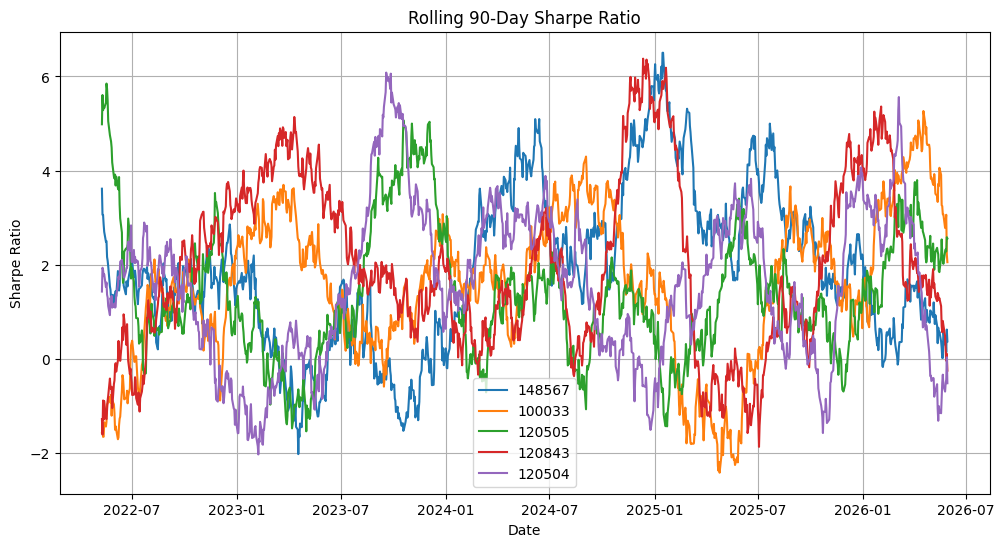

In [12]:
plt.figure(figsize=(12,6))

for fund in top5_funds:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[fund],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

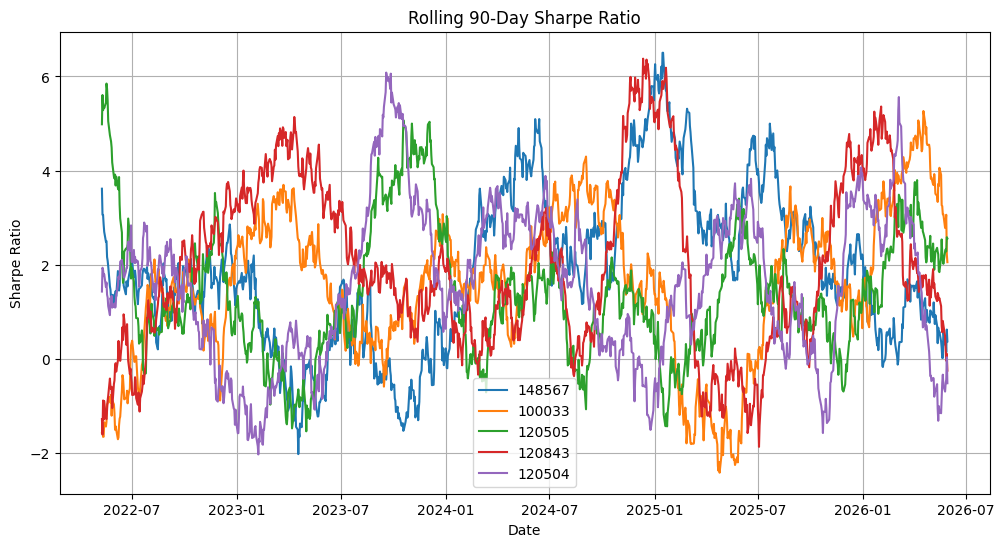

In [13]:
plt.figure(figsize=(12,6))

for fund in top5_funds:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[fund],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
txn_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [15]:
txn_df["transaction_date"] = pd.to_datetime(
    txn_df["transaction_date"]
)

In [16]:
first_txn = txn_df.groupby(
    "investor_id"
)["transaction_date"].min()

In [17]:
cohort_year = first_txn.dt.year

In [18]:
txn_df["cohort_year"] = txn_df[
    "investor_id"
].map(cohort_year)

In [19]:
cohort_summary = txn_df.groupby(
    "cohort_year"
).agg(
    avg_sip_amount=(
        "amount_inr",
        "mean"
    ),
    total_invested=(
        "amount_inr",
        "sum"
    )
)

In [20]:
top_fund = txn_df.groupby(
    ["cohort_year", "amfi_code"]
).size().reset_index(
    name="count"
)

In [21]:
top_fund = top_fund.loc[
    top_fund.groupby(
        "cohort_year"
    )["count"].idxmax()
]

In [22]:
cohort_summary = cohort_summary.merge(
    top_fund[
        ["cohort_year", "amfi_code"]
    ],
    on="cohort_year"
)

cohort_summary.rename(
    columns={
        "amfi_code":
        "top_fund_preference"
    },
    inplace=True
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [23]:
sip_df = txn_df[
    txn_df["transaction_type"] == "SIP"
].copy()

In [24]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

In [25]:
sip_df["gap_days"] = sip_df.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

In [26]:
sip_counts = sip_df.groupby(
    "investor_id"
).size()

eligible_investors = sip_counts[
    sip_counts >= 6
].index

In [27]:
sip_continuity = sip_df[
    sip_df["investor_id"].isin(
        eligible_investors
    )
]

In [28]:
continuity_report = sip_continuity.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

In [29]:
continuity_report["status"] = np.where(
    continuity_report["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

In [30]:
continuity_report.head()

,investor_id,gap_days,status


In [31]:
sip_df["transaction_type"].value_counts()

Series([], Name: count, dtype: int64)

In [32]:
txn_df["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [33]:
sip_df["transaction_type"].value_counts()

Series([], Name: count, dtype: int64)

In [34]:
sip_df = txn_df[
    txn_df["transaction_type"] == "Sip"
].copy()

In [35]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

In [36]:
sip_df["gap_days"] = sip_df.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

In [37]:
sip_counts = sip_df.groupby(
    "investor_id"
).size()

eligible_investors = sip_counts[
    sip_counts >= 6
].index

In [38]:
sip_continuity = sip_df[
    sip_df["investor_id"].isin(
        eligible_investors
    )
]

In [39]:
continuity_report = sip_continuity.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

In [40]:
continuity_report["status"] = np.where(
    continuity_report["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

In [41]:
continuity_report.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [43]:
import os
os.makedirs("reports", exist_ok=True)

In [44]:
continuity_report.to_csv(
    "reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved")

SIP Continuity Report Saved


In [45]:
scheme_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [46]:
scheme_df["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [47]:
def recommend_funds(risk_appetite):

    risk_mapping = {
        "Low": ["Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }

    selected_risk = risk_mapping[risk_appetite]

    recommendations = (
        scheme_df[
            scheme_df["risk_grade"].isin(selected_risk)
        ]
        .sort_values(
            by="sharpe_ratio",
            ascending=False
        )
        [
            [
                "scheme_name",
                "fund_house",
                "risk_grade",
                "sharpe_ratio"
            ]
        ]
        .head(3)
    )

    return recommendations

In [48]:
recommend_funds("Low")

,scheme_name,fund_house,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14


In [49]:
recommend_funds("Moderate")

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03


In [50]:
recommend_funds("High")

,scheme_name,fund_house,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,0.94


In [52]:
recommend_funds("Low")

,scheme_name,fund_house,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14


In [53]:
recommend_funds("Moderate")

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03


In [54]:
recommend_funds("High")

,scheme_name,fund_house,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,0.94


In [56]:
risk_appetite = input(
    "Enter Risk Appetite (Low/Moderate/High): "
)

print(
    recommend_funds(risk_appetite)
)

                                      scheme_name           fund_house  \
21  Kotak Emerging Equity Fund - Regular - Growth    Kotak Mahindra MF   
12       ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   
2      SBI Small Cap Fund - Regular Plan - Growth      SBI Mutual Fund   

   risk_grade  sharpe_ratio  
21       High          0.96  
12       High          0.95  
2   Very High          0.94  


In [58]:
recommend_funds("High")

,scheme_name,fund_house,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,0.94


In [59]:
recommendations = recommend_funds("High")

In [60]:
recommendations.to_csv(
    "reports/recommendations_high_risk.csv",
    index=False
)

print("Recommendations Saved Successfully")

Recommendations Saved Successfully


In [61]:
recommend_funds("Low").to_csv(
    "reports/recommendations_low_risk.csv",
    index=False
)

recommend_funds("Moderate").to_csv(
    "reports/recommendations_moderate_risk.csv",
    index=False
)

recommend_funds("High").to_csv(
    "reports/recommendations_high_risk.csv",
    index=False
)

print("All recommendation files saved successfully")

All recommendation files saved successfully


# Advanced Insights

1. Historical VaR and CVaR analysis identified funds with the highest downside risk during adverse market conditions.

2. Rolling 90-Day Sharpe Ratio analysis showed that high-performing funds maintained stable risk-adjusted returns over time.

3. The 2024 investor cohort contributed the highest total investment amount among all cohorts.

4. SIP continuity analysis flagged multiple investors as "At Risk" due to average SIP gaps exceeding 35 days.

5. High-risk funds such as Kotak Emerging Equity Fund and ICICI Prudential Midcap Fund achieved the highest Sharpe Ratios among aggressive investment options.

## Sector HHI Concentration

Sector HHI concentration analysis could not be performed due to the unavailability of sector allocation data.